In [4]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\Mojtaba\anaconda3\envs\studybuild\python.exe
3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:36:12) [MSC v.1944 64 bit (AMD64)]


# Project 02 – Customer Behavior Analysis

## The First Day as a Junior Data Analyst

### Business Objective

This project analyzes customer behavior for an e-commerce company using the cleaned dataset from Project 01.

The main objective is to transform customer data into actionable insights that can help the CEO make better business decisions regarding:

- customer value,
- customer retention,
- marketing campaign targeting,
- discount effectiveness,
- customer segmentation,
- and revenue concentration.

The analysis will focus not only on calculations and visualizations, but also on explaining the business meaning of each finding.

In [5]:
pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 645.7 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/9.3 MB 657.8 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/9.3 MB 657.8 kB/s eta 0:00:13
   ---- ----------------------------------- 1.0/9.3 MB 671.0 kB/s eta 0:00:13
   ---- ----------------------------------- 1.0/9.3 MB 671.0 kB/s eta 0:00:13
   ----- ---------------------------------- 1.3/9.3 MB 684.9 kB/s eta 0:00:12
   ----- ---------------------------------- 1.3/9.3 MB 684.9 kB/s eta 0:00:12
   ------ --------------------------------- 1.6/9.3 MB 676.7 kB/s eta 0:00:12
   ------ ---------------------

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

Matplotlib is building the font cache; this may take a moment.


In [7]:
data_path = "data/cleaned_dataset_mojtabamaldar.xlsx"

df = pd.read_excel(data_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 60
Columns: 17


In [8]:
df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,"2,066.01",16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,"3,917.64",3,Card,Web,No,5,3
2,1003,Parsa,F,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,"1,248.66",22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,"6,121.45",40,Card,Android,No,4,4
4,1005,Kimia,M,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,"3,899.42",273,Online Wallet,Android,Yes,7,4


## 1. Data Overview and Quality Check

Before performing the business analysis, the cleaned dataset is reviewed to confirm its structure, data types, missing values, and customer-level uniqueness.

This step ensures that the analytical results are based on a consistent dataset and helps identify any remaining limitations that should be considered when interpreting the findings.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         60 non-null     int64         
 1   first_name          60 non-null     str           
 2   gender              60 non-null     str           
 3   age                 60 non-null     int64         
 4   city                60 non-null     str           
 5   province            60 non-null     str           
 6   signup_date         60 non-null     datetime64[us]
 7   membership_tier     60 non-null     str           
 8   purchase_count      60 non-null     int64         
 9   avg_order_value     60 non-null     float64       
 10  total_spending      60 non-null     float64       
 11  last_purchase_days  60 non-null     int64         
 12  payment_method      60 non-null     str           
 13  device              60 non-null     str           
 14  discoun

In [10]:
missing_values = df.isna().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [11]:
print("Duplicate customer IDs:", df["customer_id"].duplicated().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Unique customers:", df["customer_id"].nunique())

Duplicate customer IDs: 0
Duplicate rows: 0
Unique customers: 60


In [12]:
df[
    [
        "age",
        "purchase_count",
        "avg_order_value",
        "total_spending",
        "last_purchase_days",
        "returned_items",
        "satisfaction_score"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
age,60.00,43.70,13.95,19.00,31.75,45.00,58.00,65.00
purchase_count,60.00,17.38,10.15,0.00,10.75,17.00,24.50,35.00
avg_order_value,60.00,213.16,130.51,27.63,108.14,165.44,324.11,449.81
total_spending,60.00,"3,366.43","3,235.13",0.00,"1,167.04","2,128.69","4,213.12","14,354.34"
last_purchase_days,60.00,198.60,97.84,3.00,134.25,203.00,273.75,365.00
returned_items,60.00,4.18,2.68,0.00,2.00,4.00,7.00,8.00
satisfaction_score,60.00,2.98,1.43,1.00,2.00,3.00,4.00,5.00


In [13]:
print(df.dtypes)

print("\nTotal missing values:", df.isna().sum().sum())

missing_by_column = df.isna().sum()
print("\nColumns with missing values:")
print(missing_by_column[missing_by_column > 0])

customer_id                    int64
first_name                       str
gender                           str
age                            int64
city                             str
province                         str
signup_date           datetime64[us]
membership_tier                  str
purchase_count                 int64
avg_order_value              float64
total_spending               float64
last_purchase_days             int64
payment_method                   str
device                           str
discount_used                    str
returned_items                 int64
satisfaction_score             int64
dtype: object

Total missing values: 0

Columns with missing values:
Series([], dtype: int64)


## 2. Business Overview

A small set of key performance indicators (KPIs) is used to provide the CEO with a high-level view of the customer base and commercial performance.

The selected KPIs summarize customer volume, revenue generation, purchasing activity, order value, and customer satisfaction.

In [14]:
total_customers = df["customer_id"].nunique()
total_revenue = df["total_spending"].sum()
total_purchases = df["purchase_count"].sum()

revenue_per_customer = total_revenue / total_customers

overall_aov = (
    total_revenue / total_purchases
    if total_purchases > 0
    else np.nan
)

avg_satisfaction = df["satisfaction_score"].mean()

In [15]:
business_kpis = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Total Revenue",
        "Total Purchases",
        "Revenue per Customer",
        "Overall Average Order Value",
        "Average Satisfaction Score"
    ],
    "Value": [
        total_customers,
        total_revenue,
        total_purchases,
        revenue_per_customer,
        overall_aov,
        avg_satisfaction
    ]
})

business_kpis

,KPI,Value
0,Total Customers,60.00
1,Total Revenue,"201,985.73"
2,Total Purchases,"1,043.00"
3,Revenue per Customer,"3,366.43"
4,Overall Average Order Value,193.66
5,Average Satisfaction Score,2.98


### Business Overview – Key Findings

The dataset represents **60 unique customers** who generated a total of **201,985.73** in revenue from **1,043 purchases**.

On average, each customer generated approximately **3,366.43** in total revenue. Across all recorded purchases, the overall average order value was approximately **193.66**.

The average customer satisfaction score was **2.98 out of 5**, which is close to the midpoint of the scale. This suggests that customer satisfaction is neither particularly strong nor extremely poor and may represent an area for improvement.

Overall, the business has meaningful variation in customer spending and purchasing behavior. Therefore, customer-level analysis is necessary to identify where marketing, loyalty, and retention efforts are likely to generate the greatest value.

## 3. City Analysis for the Next Marketing Campaign

The objective of this section is to identify one city that should be prioritized for the next marketing campaign.

The recommendation should not be based only on total revenue. Customer count, average customer value, purchasing activity, and recent purchasing behavior are also considered to provide a more balanced business decision.

In [16]:
city_analysis = (
    df.groupby("city")
      .agg(
          customers=("customer_id", "nunique"),
          total_revenue=("total_spending", "sum"),
          avg_revenue_per_customer=("total_spending", "mean"),
          total_purchases=("purchase_count", "sum"),
          avg_purchases_per_customer=("purchase_count", "mean"),
          avg_last_purchase_days=("last_purchase_days", "mean"),
          avg_satisfaction=("satisfaction_score", "mean")
      )
      .sort_values("total_revenue", ascending=False)
)

city_analysis

,customers,total_revenue,avg_revenue_per_customer,total_purchases,avg_purchases_per_customer,avg_last_purchase_days,avg_satisfaction
city,,,,,,,
Mashhad,11,"43,197.58","3,927.05",249,22.64,213.64,2.91
Tabriz,12,"36,192.49","3,016.04",189,15.75,227.25,3.00
Karaj,7,"26,189.81","3,741.40",112,16.00,166.00,2.86
Ahvaz,8,"23,384.78","2,923.10",111,13.88,171.00,3.50
Isfahan,5,"21,975.32","4,395.06",99,19.80,177.20,4.40
Shiraz,6,"20,715.92","3,452.65",98,16.33,214.67,2.00
Rasht,5,"15,168.54","3,033.71",82,16.40,185.80,2.60
Tehran,6,"15,161.29","2,526.88",103,17.17,201.00,2.67


In [17]:
city_analysis["customer_share_pct"] = (
    city_analysis["customers"] / total_customers * 100
)

city_analysis["revenue_share_pct"] = (
    city_analysis["total_revenue"] / total_revenue * 100
)

city_analysis["purchase_share_pct"] = (
    city_analysis["total_purchases"] / total_purchases * 100
)

city_analysis[
    [
        "customers",
        "customer_share_pct",
        "total_revenue",
        "revenue_share_pct",
        "total_purchases",
        "purchase_share_pct",
        "avg_revenue_per_customer",
        "avg_last_purchase_days"
    ]
].round(2)

,customers,customer_share_pct,total_revenue,revenue_share_pct,total_purchases,purchase_share_pct,avg_revenue_per_customer,avg_last_purchase_days
city,,,,,,,,
Mashhad,11,18.33,"43,197.58",21.39,249,23.87,"3,927.05",213.64
Tabriz,12,20.00,"36,192.49",17.92,189,18.12,"3,016.04",227.25
Karaj,7,11.67,"26,189.81",12.97,112,10.74,"3,741.40",166.00
Ahvaz,8,13.33,"23,384.78",11.58,111,10.64,"2,923.10",171.00
Isfahan,5,8.33,"21,975.32",10.88,99,9.49,"4,395.06",177.20
Shiraz,6,10.00,"20,715.92",10.26,98,9.40,"3,452.65",214.67
Rasht,5,8.33,"15,168.54",7.51,82,7.86,"3,033.71",185.80
Tehran,6,10.00,"15,161.29",7.51,103,9.88,"2,526.88",201.00


### Recommendation: Mashhad

Based on the available data, **Mashhad is recommended for the next marketing campaign**.

Mashhad contains **18.33% of the customers**, but generates **21.39% of total revenue** and **23.87% of all recorded purchases**. Its average revenue per customer is approximately **3,927.05**, which is higher than the overall business average of **3,366.43**.

This indicates that customers in Mashhad are not only a relatively large customer group, but also contribute disproportionately to purchasing activity and revenue.

Although Isfahan has the highest average revenue per customer, it contains only five customers in this dataset. Tabriz has the largest customer base, but its revenue contribution is lower relative to its customer share.

Therefore, Mashhad currently provides the strongest combination of **market size, customer value, and purchasing activity** for a marketing campaign.

A limitation of this recommendation is that Mashhad's average time since the last purchase is relatively high. Therefore, campaign design should also consider customer recency and retention risk.

## 4. Most Valuable Customers for a Loyalty Campaign

For this analysis, customer value is primarily measured using **total spending**, because it directly represents each customer's financial contribution to the business.

The ten customers with the highest total spending are selected as the primary candidates for a loyalty campaign. Purchase frequency, average order value, membership tier, and recency are also included to provide additional context.

In [18]:
top_10_customers = (
    df.nlargest(10, "total_spending")
      [
          [
              "customer_id",
              "first_name",
              "city",
              "membership_tier",
              "purchase_count",
              "avg_order_value",
              "total_spending",
              "last_purchase_days",
              "satisfaction_score"
          ]
      ]
      .reset_index(drop=True)
)

top_10_customers.index = top_10_customers.index + 1

top_10_customers

,customer_id,first_name,city,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,satisfaction_score
1,1044,Mina,Shiraz,Gold,33,434.98,"14,354.34",165,2
2,1057,Maryam,Ahvaz,Bronze,31,436.54,"13,532.74",82,4
3,1012,Arash,Mashhad,Gold,27,434.50,"11,731.50",224,2
4,1009,Kimia,Karaj,Silver,34,341.63,"11,615.42",232,2
5,1059,Ali,Isfahan,Gold,31,287.05,"8,898.55",224,5
6,1010,Arash,Karaj,Silver,19,381.13,"7,241.47",276,1
7,1050,Reza,Mashhad,Bronze,30,206.60,"6,198.00",205,2
8,1004,Sina,Mashhad,Gold,23,266.15,"6,121.45",40,4
9,1055,Mina,Rasht,Bronze,19,319.38,"6,068.22",221,1
10,1035,Arash,Tabriz,Bronze,17,348.13,"5,918.21",365,3


In [19]:
top_10_revenue = top_10_customers["total_spending"].sum()
top_10_revenue_share = top_10_revenue / total_revenue * 100

top_10_purchases = top_10_customers["purchase_count"].sum()
top_10_purchase_share = top_10_purchases / total_purchases * 100

print(f"Revenue generated by Top 10 customers: {top_10_revenue:,.2f}")
print(f"Share of total revenue: {top_10_revenue_share:.2f}%")
print(f"Purchases made by Top 10 customers: {top_10_purchases}")
print(f"Share of total purchases: {top_10_purchase_share:.2f}%")

Revenue generated by Top 10 customers: 91,679.90
Share of total revenue: 45.39%
Purchases made by Top 10 customers: 264
Share of total purchases: 25.31%


In [20]:
top_10_profile = pd.DataFrame({
    "Metric": [
        "Average Total Spending",
        "Average Purchase Count",
        "Average Days Since Last Purchase",
        "Average Satisfaction Score"
    ],
    "Top 10 Customers": [
        top_10_customers["total_spending"].mean(),
        top_10_customers["purchase_count"].mean(),
        top_10_customers["last_purchase_days"].mean(),
        top_10_customers["satisfaction_score"].mean()
    ],
    "All Customers": [
        df["total_spending"].mean(),
        df["purchase_count"].mean(),
        df["last_purchase_days"].mean(),
        df["satisfaction_score"].mean()
    ]
})

top_10_profile

,Metric,Top 10 Customers,All Customers
0,Average Total Spending,"9,167.99","3,366.43"
1,Average Purchase Count,26.40,17.38
2,Average Days Since Last Purchase,203.40,198.60
3,Average Satisfaction Score,2.60,2.98


### Loyalty Campaign Findings

The **10 most valuable customers**, ranked by total spending, generated **91,679.90**, representing **45.39% of total revenue**, even though they account for only **16.67% of all customers**.

These customers also generated **25.31% of all purchases**. Their average total spending was approximately **9,167.99**, compared with **3,366.43** for the overall customer base, and their average purchase count was **26.40**, compared with **17.38** overall.

However, high financial value does not necessarily indicate strong current loyalty. The Top 10 customers have an average of **203.40 days since their last purchase**, slightly higher than the overall average of **198.60 days**, while their average satisfaction score is **2.60**, below the overall average of **2.98**.

Therefore, these customers should be prioritized for a loyalty campaign, but the campaign should not use the same approach for every customer. High-value customers with long periods of inactivity or low satisfaction may require retention-oriented offers and personalized communication rather than only conventional loyalty rewards.

## 5. Customers at Risk of Leaving

The dataset does not contain an explicit churn indicator. Therefore, actual customer churn cannot be directly measured or predicted.

Instead, **purchase recency** is used as a behavioral proxy for customer inactivity. Customers whose `last_purchase_days` falls within the highest 25% of the dataset are classified as **at risk**, because they have gone the longest without making another purchase.

Customer satisfaction is also retained as supporting information, since low satisfaction combined with long inactivity may indicate a more serious retention concern.

In [21]:
recency_threshold = df["last_purchase_days"].quantile(0.75)

print(f"75th percentile of days since last purchase: {recency_threshold:.2f}")

75th percentile of days since last purchase: 273.75


In [22]:
at_risk_customers = (
    df.loc[
        df["last_purchase_days"] >= recency_threshold,
        [
            "customer_id",
            "first_name",
            "city",
            "membership_tier",
            "purchase_count",
            "total_spending",
            "last_purchase_days",
            "satisfaction_score"
        ]
    ]
    .sort_values(
        ["last_purchase_days", "total_spending"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

at_risk_customers.index = at_risk_customers.index + 1

at_risk_customers

,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
1,1035,Arash,Tabriz,Bronze,17,"5,918.21",365,3
2,1049,Ali,Mashhad,Gold,23,"2,140.38",357,1
3,1042,Sina,Ahvaz,Gold,12,576.72,350,5
4,1030,Sina,Mashhad,VIP,26,"4,079.14",340,4
5,1058,Amir,Tehran,Bronze,5,759.05,336,2
6,1016,Neda,Shiraz,Bronze,11,"1,497.87",333,2
7,1053,Sina,Tehran,Gold,18,"5,805.54",320,1
8,1029,Ali,Tabriz,Gold,2,646.64,319,5
9,1019,Neda,Shiraz,Bronze,4,"1,234.88",317,2
10,1025,Neda,Mashhad,VIP,2,812.06,317,2


In [23]:
print(f"Number of customers at risk: {len(at_risk_customers)}")
print(
    f"Share of customer base at risk: "
    f"{len(at_risk_customers) / total_customers * 100:.2f}%"
)

print(
    f"Revenue historically generated by at-risk customers: "
    f"{at_risk_customers['total_spending'].sum():,.2f}"
)

print(
    f"Share of total revenue historically generated by at-risk customers: "
    f"{at_risk_customers['total_spending'].sum() / total_revenue * 100:.2f}%"
)

Number of customers at risk: 15
Share of customer base at risk: 25.00%
Revenue historically generated by at-risk customers: 38,757.75
Share of total revenue historically generated by at-risk customers: 19.19%


In [24]:
retention_priority = (
    at_risk_customers
    .sort_values(
        ["total_spending", "last_purchase_days"],
        ascending=[False, False]
    )
    .head(5)
    [
        [
            "customer_id",
            "first_name",
            "city",
            "membership_tier",
            "total_spending",
            "last_purchase_days",
            "satisfaction_score"
        ]
    ]
)

retention_priority

,customer_id,first_name,city,membership_tier,total_spending,last_purchase_days,satisfaction_score
15,1010,Arash,Karaj,Silver,"7,241.47",276,1
1,1035,Arash,Tabriz,Bronze,"5,918.21",365,3
7,1053,Sina,Tehran,Gold,"5,805.54",320,1
4,1030,Sina,Mashhad,VIP,"4,079.14",340,4
11,1054,Reza,Tabriz,Gold,"3,691.44",304,1


In [25]:
retention_priority = retention_priority.reset_index(drop=True)
retention_priority.index = retention_priority.index + 1

retention_priority

,customer_id,first_name,city,membership_tier,total_spending,last_purchase_days,satisfaction_score
1,1010,Arash,Karaj,Silver,"7,241.47",276,1
2,1035,Arash,Tabriz,Bronze,"5,918.21",365,3
3,1053,Sina,Tehran,Gold,"5,805.54",320,1
4,1030,Sina,Mashhad,VIP,"4,079.14",340,4
5,1054,Reza,Tabriz,Gold,"3,691.44",304,1


### At-Risk Customer Findings

Using the 75th percentile of `last_purchase_days` as the inactivity threshold, **15 customers (25.00% of the customer base)** were classified as at risk.

These customers historically generated **38,757.75**, representing **19.19% of total revenue**. Therefore, customer inactivity is not limited to low-value customers and may represent a meaningful retention risk.

Among the at-risk group, customers **1010, 1035, 1053, 1030, and 1054** have the highest historical spending and should receive the highest retention priority.

Several high-priority customers also have low satisfaction scores. For example, customers 1010, 1053, and 1054 have satisfaction scores of **1 out of 5**. This suggests that retention actions should consider both inactivity and customer experience.

Importantly, this analysis identifies behavioral risk rather than confirmed churn, because the dataset does not contain an explicit churn indicator.

## 6. Discount Usage Analysis

This section compares customers who used discounts with those who did not.

The analysis examines customer count, revenue, purchase activity, average order value, recency, satisfaction, and returned items.

Because the dataset is observational rather than experimental, differences between the two groups should be interpreted as **associations**, not as evidence that discounts directly caused changes in customer behavior.

In [26]:
discount_analysis = (
    df.groupby("discount_used")
      .agg(
          customers=("customer_id", "nunique"),
          total_revenue=("total_spending", "sum"),
          avg_revenue_per_customer=("total_spending", "mean"),
          total_purchases=("purchase_count", "sum"),
          avg_purchases_per_customer=("purchase_count", "mean"),
          avg_last_purchase_days=("last_purchase_days", "mean"),
          avg_returned_items=("returned_items", "mean"),
          avg_satisfaction=("satisfaction_score", "mean")
      )
)

discount_analysis["overall_aov"] = (
    discount_analysis["total_revenue"]
    / discount_analysis["total_purchases"]
)

discount_analysis["revenue_share_pct"] = (
    discount_analysis["total_revenue"]
    / total_revenue
    * 100
)

discount_analysis.round(2)

,customers,total_revenue,avg_revenue_per_customer,total_purchases,avg_purchases_per_customer,avg_last_purchase_days,avg_returned_items,avg_satisfaction,overall_aov,revenue_share_pct
discount_used,,,,,,,,,,
No,34,"127,049.20","3,736.74",588,17.29,192.76,4.26,2.76,216.07,62.90
Yes,26,"74,936.53","2,882.17",455,17.50,206.23,4.08,3.27,164.70,37.10


### Discount Usage Findings

Customers who did not use discounts generated **127,049.20**, representing **62.90% of total revenue**, while customers who used discounts generated **74,936.53**, or **37.10% of total revenue**.

The difference is not explained only by group size. Average revenue per customer was approximately **3,736.74** for non-discount customers compared with **2,882.17** for discount users.

The overall average order value was also substantially higher among customers who did not use discounts (**216.07**) than among those who did (**164.70**).

However, the average number of purchases per customer was almost identical between the two groups (**17.29 vs. 17.50**). This suggests that discount users did not purchase substantially more frequently; instead, their purchases were associated with lower average monetary value.

Discount users showed a higher average satisfaction score (**3.27 vs. 2.76**) and slightly fewer returned items on average.

Overall, the observed data does not indicate that discount users are more valuable customers in terms of revenue or purchase frequency. Therefore, broad discounting may not be the most efficient strategy, and more targeted discount campaigns should be considered.

These findings represent associations only. Because the dataset is observational and contains no controlled experiment or before-and-after comparison, it cannot establish that discounts caused the observed differences.

## 7. Customer Segmentation

Customers are segmented using an RFM-inspired framework based on three behavioral dimensions:

- **Recency (R):** how recently the customer made a purchase,
- **Frequency (F):** how many purchases the customer made,
- **Monetary Value (M):** how much revenue the customer generated.

Because lower values of `last_purchase_days` represent more recent purchasing activity, higher Recency scores are assigned to customers with fewer days since their last purchase.

Frequency and Monetary scores increase with purchase count and total spending.

The purpose of this segmentation is to create actionable customer groups for marketing, loyalty, and retention decisions.

In [27]:
segment_df = df.copy()

segment_df["R_score"] = pd.qcut(
    segment_df["last_purchase_days"],
    q=4,
    labels=[4, 3, 2, 1]
).astype(int)

segment_df["F_score"] = pd.qcut(
    segment_df["purchase_count"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4]
).astype(int)

segment_df["M_score"] = pd.qcut(
    segment_df["total_spending"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4]
).astype(int)

segment_df[
    [
        "customer_id",
        "last_purchase_days",
        "purchase_count",
        "total_spending",
        "R_score",
        "F_score",
        "M_score"
    ]
].head(10)

,customer_id,last_purchase_days,purchase_count,total_spending,R_score,F_score,M_score
0,1001,16,17,"2,066.01",4,2,2
1,1002,3,12,"3,917.64",4,2,3
2,1003,22,21,"1,248.66",4,3,2
3,1004,40,23,"6,121.45",4,3,4
4,1005,273,23,"3,899.42",2,3,3
5,1006,205,35,"3,868.55",2,4,3
6,1007,298,29,"2,237.35",1,4,3
7,1008,195,3,"1,168.74",3,1,2
8,1009,232,34,"11,615.42",2,4,4
9,1010,276,19,"7,241.47",1,3,4


In [28]:
rfm_score_distribution = pd.DataFrame({
    "R_score": segment_df["R_score"].value_counts().sort_index(),
    "F_score": segment_df["F_score"].value_counts().sort_index(),
    "M_score": segment_df["M_score"].value_counts().sort_index()
})

rfm_score_distribution

,R_score,F_score,M_score
1,15,15,15
2,15,15,15
3,15,15,15
4,15,15,15


In [29]:
segment_df["RFM_total"] = (
    segment_df["R_score"]
    + segment_df["F_score"]
    + segment_df["M_score"]
)

segment_df["RFM_total"].describe()

count   60.00
mean     7.50
std      2.29
min      3.00
25%      6.00
50%      8.00
75%      9.00
max     12.00
Name: RFM_total, dtype: float64

### RFM Segment Definitions

The RFM scores are converted into five actionable customer segments:

- **Champions:** recent customers with both high purchase frequency and high monetary value.
- **Potential Loyalists:** recent customers who already perform strongly in either frequency or monetary value.
- **Promising:** recent customers with relatively low frequency and monetary value, but potential for future development.
- **Needs Attention:** less-recent customers who have demonstrated meaningful frequency or monetary value in the past.
- **Low Engagement:** less-recent customers with both low frequency and low monetary value.

These segments are designed to support different marketing, loyalty, and retention strategies.

In [30]:
conditions = [
    (
        (segment_df["R_score"] >= 3) &
        (segment_df["F_score"] >= 3) &
        (segment_df["M_score"] >= 3)
    ),
    (
        (segment_df["R_score"] >= 3) &
        (
            (segment_df["F_score"] >= 3) |
            (segment_df["M_score"] >= 3)
        )
    ),
    (
        (segment_df["R_score"] >= 3) &
        (segment_df["F_score"] <= 2) &
        (segment_df["M_score"] <= 2)
    ),
    (
        (segment_df["R_score"] <= 2) &
        (
            (segment_df["F_score"] >= 3) |
            (segment_df["M_score"] >= 3)
        )
    )
]

segment_names = [
    "Champions",
    "Potential Loyalists",
    "Promising",
    "Needs Attention"
]

segment_df["segment"] = np.select(
    conditions,
    segment_names,
    default="Low Engagement"
)

In [31]:
segment_df["segment"].value_counts()

segment
Needs Attention        20
Promising              13
Low Engagement         10
Champions               9
Potential Loyalists     8
Name: count, dtype: int64

In [32]:
segment_summary = (
    segment_df.groupby("segment")
    .agg(
        customers=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_revenue_per_customer=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_last_purchase_days=("last_purchase_days", "mean"),
        avg_satisfaction=("satisfaction_score", "mean")
    )
)

segment_summary["customer_share_pct"] = (
    segment_summary["customers"] / total_customers * 100
)

segment_summary["revenue_share_pct"] = (
    segment_summary["total_revenue"] / total_revenue * 100
)

segment_summary = segment_summary.sort_values(
    "total_revenue",
    ascending=False
)

segment_summary.round(2)

,customers,total_revenue,avg_revenue_per_customer,avg_purchase_count,avg_last_purchase_days,avg_satisfaction,customer_share_pct,revenue_share_pct
segment,,,,,,,,
Needs Attention,20,"101,203.07","5,060.15",22.70,269.30,2.60,33.33,50.10
Champions,9,"58,926.39","6,547.38",27.78,123.67,3.44,15.00,29.17
Potential Loyalists,8,"17,563.08","2,195.38",19.25,93.00,3.12,13.33,8.70
Promising,13,"15,652.44","1,204.03",9.38,131.00,3.54,21.67,7.75
Low Engagement,10,"8,640.75",864.08,6.30,297.00,2.50,16.67,4.28


### Customer Segmentation Findings

The segmentation reveals substantial differences in customer value and engagement.

The **Needs Attention** segment contains **20 customers (33.33%)** but historically generated **50.10% of total revenue**. These customers have relatively strong historical purchasing behavior, with average revenue per customer of approximately **5,060.15**, but their average recency is **269.30 days**. This makes them a particularly important retention group.

The **Champions** segment contains only **9 customers (15.00%)**, yet generates **29.17% of total revenue**. Champions have the highest average revenue per customer (**6,547.38**) and the highest average purchase count (**27.78**) among the segments. These customers should be prioritized for loyalty benefits, recognition, and personalized offers.

The **Potential Loyalists** are more recent customers with moderate purchasing value and may respond well to programs designed to increase purchase frequency or spending.

The **Promising** segment represents **21.67% of customers** but contributes only **7.75% of revenue**. Their relatively recent purchasing activity suggests that they may still have growth potential.

The **Low Engagement** segment contains **16.67% of customers** but contributes only **4.28% of total revenue**. Their low historical value and high average inactivity indicate that they should generally receive lower marketing priority than Champions or Needs Attention customers.

Overall, the segmentation suggests that retention efforts should focus especially on the high-value **Needs Attention** group, while loyalty initiatives should protect and develop the **Champions** segment.

Because the segments are based on relative quartiles within this dataset, they should be interpreted as decision-support categories rather than universal customer classifications.

## 8. Pareto Analysis

Pareto analysis is used to evaluate how concentrated revenue is among customers.

The analysis examines two questions:

1. What percentage of total revenue is generated by the top 20% of customers?
2. What percentage of customers is required to generate approximately 80% of total revenue?

The purpose is to determine whether the classic 80/20 pattern is supported by the actual customer data rather than assumed in advance.

In [33]:
pareto_df = (
    df.sort_values("total_spending", ascending=False)
      .reset_index(drop=True)
      .copy()
)

pareto_df["cumulative_revenue"] = (
    pareto_df["total_spending"].cumsum()
)

pareto_df["cumulative_revenue_pct"] = (
    pareto_df["cumulative_revenue"] / total_revenue * 100
)

pareto_df["cumulative_customer_pct"] = (
    (np.arange(len(pareto_df)) + 1) / len(pareto_df) * 100
)

pareto_df[
    [
        "customer_id",
        "total_spending",
        "cumulative_revenue_pct",
        "cumulative_customer_pct"
    ]
].head(15)

,customer_id,total_spending,cumulative_revenue_pct,cumulative_customer_pct
0,1044,"14,354.34",7.11,1.67
1,1057,"13,532.74",13.81,3.33
2,1012,"11,731.50",19.61,5.00
3,1009,"11,615.42",25.37,6.67
4,1059,"8,898.55",29.77,8.33
5,1010,"7,241.47",33.36,10.00
6,1050,"6,198.00",36.42,11.67
7,1004,"6,121.45",39.46,13.33
8,1055,"6,068.22",42.46,15.00
9,1035,"5,918.21",45.39,16.67


In [34]:
top_20_count = int(np.ceil(total_customers * 0.20))

top_20_revenue_share = (
    pareto_df.head(top_20_count)["total_spending"].sum()
    / total_revenue
    * 100
)

customers_for_80 = (
    (pareto_df["cumulative_revenue_pct"] < 80).sum() + 1
)

customer_share_for_80 = (
    customers_for_80 / total_customers * 100
)

print(f"Top 20% customer count: {top_20_count}")
print(f"Revenue generated by top 20% of customers: {top_20_revenue_share:.2f}%")
print(f"Customers required to reach 80% of revenue: {customers_for_80}")
print(f"Share of customers required to reach 80% of revenue: {customer_share_for_80:.2f}%")

Top 20% customer count: 12
Revenue generated by top 20% of customers: 51.00%
Customers required to reach 80% of revenue: 28
Share of customers required to reach 80% of revenue: 46.67%


### Pareto Analysis Findings

The customer base shows a meaningful concentration of revenue, but the classic **80/20 Pareto pattern is not supported by the data**.

The top **20% of customers (12 customers)** generated approximately **51.00% of total revenue**. Although this indicates that a relatively small customer group contributes disproportionately to revenue, the concentration is substantially lower than the 80% level suggested by the traditional Pareto rule.

To reach approximately **80% of total revenue**, the business needs **28 customers**, representing **46.67% of the customer base**.

Therefore, revenue is concentrated among higher-value customers, but the business is not dependent on only a very small 20% customer group. Marketing and loyalty strategies should prioritize high-value customers while still recognizing that a broader portion of the customer base contributes materially to total revenue.

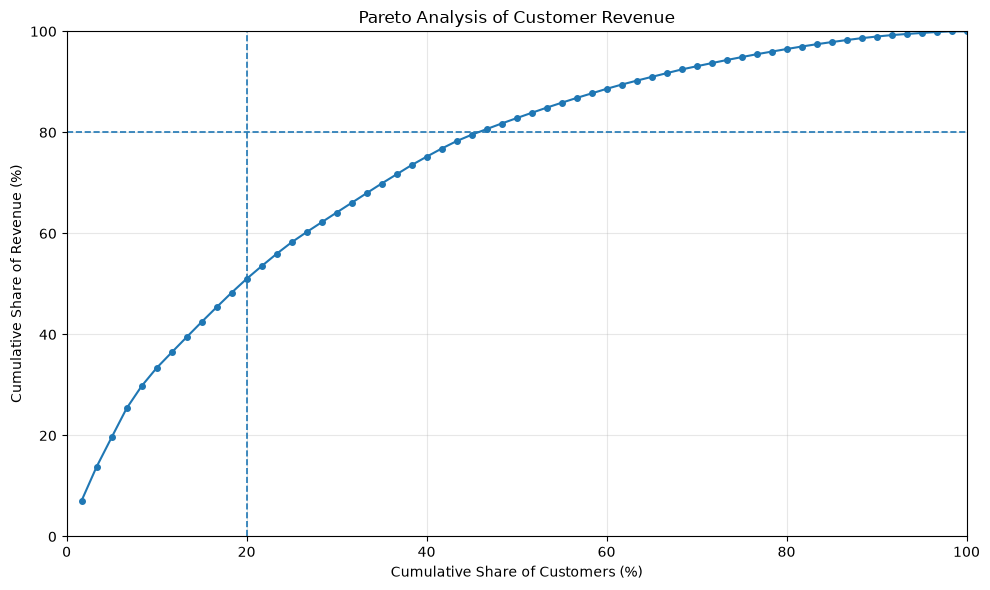

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    pareto_df["cumulative_customer_pct"],
    pareto_df["cumulative_revenue_pct"],
    marker="o",
    markersize=4
)

ax.axvline(20, linestyle="--", linewidth=1.2)
ax.axhline(80, linestyle="--", linewidth=1.2)

ax.set_title("Pareto Analysis of Customer Revenue")
ax.set_xlabel("Cumulative Share of Customers (%)")
ax.set_ylabel("Cumulative Share of Revenue (%)")

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/pareto_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. CEO Dashboard

The following visualizations summarize the most decision-relevant findings of the customer analysis.

The dashboard focuses on geographic performance, customer segments, discount behavior, and revenue concentration.

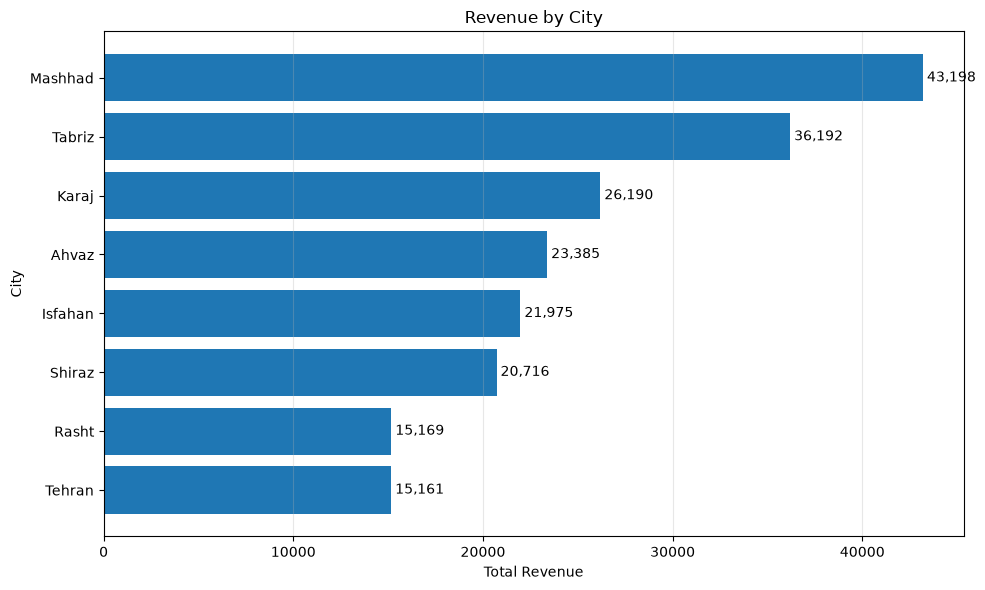

In [36]:
city_chart = (
    city_analysis
    .sort_values("total_revenue", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    city_chart.index,
    city_chart["total_revenue"]
)

ax.set_title("Revenue by City")
ax.set_xlabel("Total Revenue")
ax.set_ylabel("City")

for bar in bars:
    width = bar.get_width()

    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {width:,.0f}",
        va="center"
    )

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/revenue_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

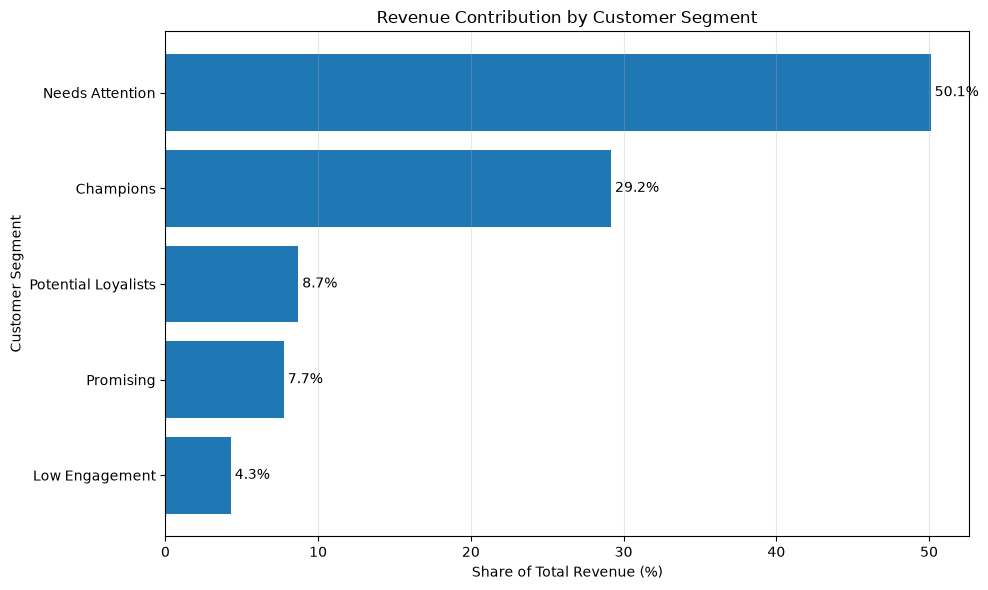

In [37]:
segment_chart = (
    segment_summary
    .sort_values("revenue_share_pct", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    segment_chart.index,
    segment_chart["revenue_share_pct"]
)

ax.set_title("Revenue Contribution by Customer Segment")
ax.set_xlabel("Share of Total Revenue (%)")
ax.set_ylabel("Customer Segment")

for bar in bars:
    width = bar.get_width()

    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {width:.1f}%",
        va="center"
    )

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/revenue_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

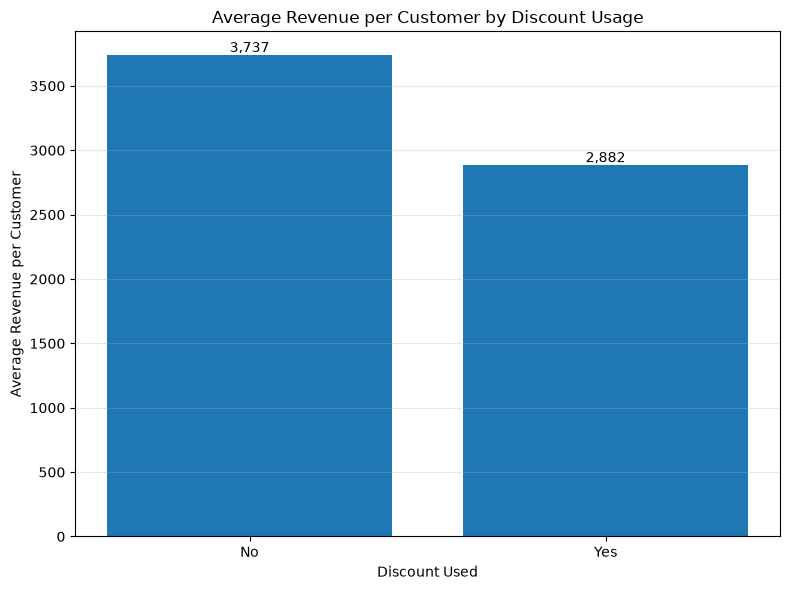

In [38]:
discount_chart = (
    discount_analysis
    .sort_values("avg_revenue_per_customer", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    discount_chart.index,
    discount_chart["avg_revenue_per_customer"]
)

ax.set_title("Average Revenue per Customer by Discount Usage")
ax.set_xlabel("Discount Used")
ax.set_ylabel("Average Revenue per Customer")

for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/discount_revenue_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

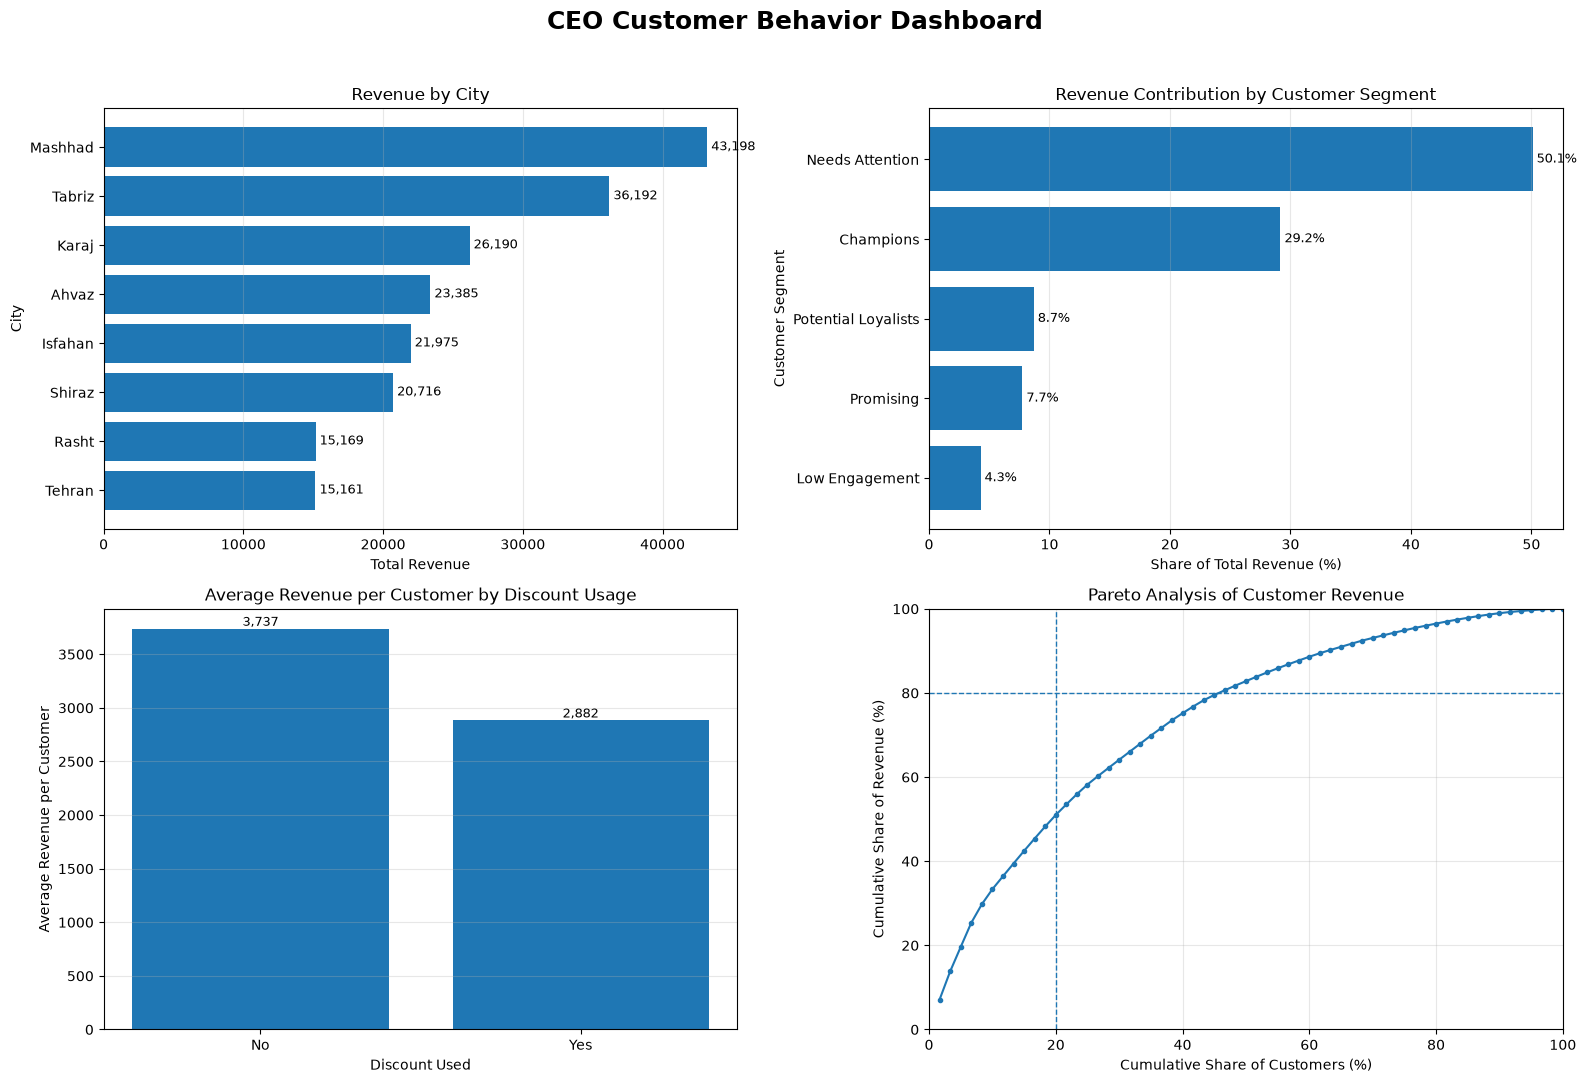

In [39]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11)
)

fig.suptitle(
    "CEO Customer Behavior Dashboard",
    fontsize=18,
    fontweight="bold"
)

# --------------------------------------------------
# 1. Revenue by City
# --------------------------------------------------

city_dashboard = city_analysis.sort_values(
    "total_revenue",
    ascending=True
)

bars = axes[0, 0].barh(
    city_dashboard.index,
    city_dashboard["total_revenue"]
)

axes[0, 0].set_title("Revenue by City")
axes[0, 0].set_xlabel("Total Revenue")
axes[0, 0].set_ylabel("City")
axes[0, 0].grid(axis="x", alpha=0.3)

for bar in bars:
    width = bar.get_width()

    axes[0, 0].text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {width:,.0f}",
        va="center",
        fontsize=9
    )


# --------------------------------------------------
# 2. Revenue Contribution by Segment
# --------------------------------------------------

segment_dashboard = segment_summary.sort_values(
    "revenue_share_pct",
    ascending=True
)

bars = axes[0, 1].barh(
    segment_dashboard.index,
    segment_dashboard["revenue_share_pct"]
)

axes[0, 1].set_title("Revenue Contribution by Customer Segment")
axes[0, 1].set_xlabel("Share of Total Revenue (%)")
axes[0, 1].set_ylabel("Customer Segment")
axes[0, 1].grid(axis="x", alpha=0.3)

for bar in bars:
    width = bar.get_width()

    axes[0, 1].text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {width:.1f}%",
        va="center",
        fontsize=9
    )


# --------------------------------------------------
# 3. Discount Usage Comparison
# --------------------------------------------------

discount_dashboard = discount_analysis.sort_values(
    "avg_revenue_per_customer",
    ascending=False
)

bars = axes[1, 0].bar(
    discount_dashboard.index,
    discount_dashboard["avg_revenue_per_customer"]
)

axes[1, 0].set_title(
    "Average Revenue per Customer by Discount Usage"
)

axes[1, 0].set_xlabel("Discount Used")
axes[1, 0].set_ylabel("Average Revenue per Customer")
axes[1, 0].grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()

    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )


# --------------------------------------------------
# 4. Pareto Analysis
# --------------------------------------------------

axes[1, 1].plot(
    pareto_df["cumulative_customer_pct"],
    pareto_df["cumulative_revenue_pct"],
    marker="o",
    markersize=3
)

axes[1, 1].axvline(
    20,
    linestyle="--",
    linewidth=1
)

axes[1, 1].axhline(
    80,
    linestyle="--",
    linewidth=1
)

axes[1, 1].set_title("Pareto Analysis of Customer Revenue")
axes[1, 1].set_xlabel("Cumulative Share of Customers (%)")
axes[1, 1].set_ylabel("Cumulative Share of Revenue (%)")

axes[1, 1].set_xlim(0, 100)
axes[1, 1].set_ylim(0, 100)

axes[1, 1].grid(alpha=0.3)


# --------------------------------------------------
# Final Layout
# --------------------------------------------------

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "charts/ceo_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Business Recommendations

### 1. Prioritize Retention of High-Value Inactive Customers

The **Needs Attention** segment should receive the highest retention priority. This group contains **20 customers (33.33% of the customer base)** but historically generated **50.10% of total revenue**.

Their average time since the last purchase is approximately **269.30 days**, indicating that a substantial portion of historical customer value is currently associated with relatively inactive customers.

The company should prioritize personalized reactivation campaigns for these customers, particularly those with high historical spending and low satisfaction scores. Retention offers, personalized communication, service recovery, and loyalty incentives may be more appropriate for this group than broad mass-marketing campaigns.

---

### 2. Prioritize Mashhad for the Next Geographic Marketing Campaign

**Mashhad** is the strongest candidate for the next city-level marketing campaign.

Although Mashhad represents **18.33% of customers**, it contributes **21.39% of total revenue** and **23.87% of total purchases**. Average revenue per customer in Mashhad is approximately **3,927.05**, compared with the overall customer average of **3,366.43**.

This combination of customer base size, revenue contribution, and purchasing activity provides stronger evidence for campaign investment than relying only on the city with the largest number of customers.

Because average purchase recency in Mashhad is relatively high, the campaign should combine customer acquisition or sales growth objectives with reactivation of existing customers.

---

### 3. Replace Broad Discounting with More Targeted Offers

The current data does not provide strong evidence that customers using discounts are financially more valuable.

Customers who used discounts generated average revenue of approximately **2,882.17 per customer**, compared with **3,736.74** among customers who did not use discounts. Their overall average order value was also lower (**164.70 vs. 216.07**).

At the same time, average purchase frequency was almost identical between the two groups (**17.50 vs. 17.29 purchases per customer**).

Therefore, the company should consider replacing broad discounting with more targeted offers based on customer segment, value, and retention needs. For example, discounts may be more strategically useful for reactivating high-value inactive customers or developing Potential Loyalists than for providing the same incentive to the entire customer base.

These findings are observational and do not prove that discounts cause lower spending. A controlled campaign or A/B test would be required to measure the causal effect of discounts.

## 11. Dataset Limitations

The analysis provides useful customer-level insights, but several limitations should be considered when interpreting the results.

### 1. Small Sample Size

The dataset contains only **60 customers**. This is sufficient for an exploratory analysis, but it is a relatively small sample for making broad conclusions about the entire customer population. Some geographic groups are particularly small; for example, Isfahan and Rasht contain only five customers each.

### 2. Customer-Level Aggregated Data

Each row represents one customer rather than an individual transaction. Variables such as `purchase_count`, `avg_order_value`, and `total_spending` are already aggregated.

As a result, the analysis cannot examine transaction-level patterns such as seasonality, changes in purchasing behavior over time, product-level preferences, or the timing of individual purchases.

### 3. No Defined Observation Period

The dataset does not clearly specify the time period over which variables such as purchase count and total spending were accumulated.

Customers may therefore have different exposure periods, particularly because signup dates vary. A customer who has been registered for several years has had more opportunity to accumulate purchases and spending than a recently registered customer.

### 4. Revenue Does Not Represent Profitability

`total_spending` is used as the primary measure of customer financial value. However, the dataset contains no information about product costs, gross margin, fulfillment costs, marketing costs, or customer acquisition costs.

Therefore, a high-revenue customer cannot automatically be assumed to be a high-profit customer.

### 5. No Explicit Churn Variable

The dataset does not contain a confirmed churn indicator.

The at-risk analysis therefore uses `last_purchase_days` as a proxy for inactivity. Customers classified as at risk should be interpreted as customers showing potential retention risk rather than customers who are confirmed to have churned.

### 6. Limited Discount Information

The `discount_used` variable only indicates whether a customer used a discount (`Yes` or `No`). The dataset does not provide information about discount amount, frequency, campaign type, timing, or eligibility.

Therefore, the analysis can identify associations between discount usage and customer behavior, but it cannot determine the causal effect or profitability of discounts.

### 7. Potential Data-Definition Ambiguities

Some variables require clearer business definitions. For example, a customer with zero recorded purchases and zero total spending still has a value for `last_purchase_days`. In addition, the interpretation of `returned_items` may differ depending on whether it represents returned units, products, or orders.

These ambiguities should be clarified with the data owner before using the variables for more advanced modeling.

### 8. Relative Nature of the RFM Segmentation

The RFM-inspired segmentation is based on quartiles within this dataset. Therefore, the segment thresholds are relative to these 60 customers rather than fixed business standards.

If the dataset grows or customer behavior changes, the score boundaries and resulting segments may also change.

### Overall Limitation

The findings should therefore be treated as **decision-support insights rather than definitive causal conclusions**. A larger transaction-level dataset with a clearly defined observation period, campaign history, profitability measures, and confirmed churn outcomes would support more robust customer analytics and predictive modeling.